The Nobel Prize has been among the most prestigious international awards since 1901. Each year, awards are bestowed in chemistry, literature, physics, physiology or medicine, economics, and peace. In addition to the honor, prestige, and substantial prize money, the recipient also gets a gold medal with an image of Alfred Nobel (1833 - 1896), who established the prize.

![](Nobel_Prize.png)

The Nobel Foundation has made a dataset available of all prize winners from the outset of the awards from 1901 to 2023. The dataset used in this project is from the Nobel Prize API and is available in the `nobel.csv` file in the `data` folder.

In this project, you'll get a chance to explore and answer several questions related to this prizewinning data. And we encourage you then to explore further questions that you're interested in!

In [102]:
# Loading in required libraries
import pandas as pd
import seaborn as sns
import numpy as np
import os


In [103]:
df = pd.read_csv('data/nobel.csv')

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   year                  1000 non-null   int64 
 1   category              1000 non-null   object
 2   prize                 1000 non-null   object
 3   motivation            912 non-null    object
 4   prize_share           1000 non-null   object
 5   laureate_id           1000 non-null   int64 
 6   laureate_type         1000 non-null   object
 7   full_name             1000 non-null   object
 8   birth_date            968 non-null    object
 9   birth_city            964 non-null    object
 10  birth_country         969 non-null    object
 11  sex                   970 non-null    object
 12  organization_name     736 non-null    object
 13  organization_city     735 non-null    object
 14  organization_country  735 non-null    object
 15  death_date            596 non-null    o

In [105]:
df.head()

,year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,birth_country,sex,organization_name,organization_city,organization_country,death_date,death_city,death_country
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,160,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Male,Berlin University,Berlin,Germany,1911-03-01,Berlin,Germany
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,569,Individual,Sully Prudhomme,1839-03-16,Paris,France,Male,NaN,NaN,NaN,1907-09-07,Châtenay,France
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,293,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Male,Marburg University,Marburg,Germany,1917-03-31,Marburg,Germany
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,462,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Male,NaN,NaN,NaN,1910-10-30,Heiden,Switzerland
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,463,Individual,Frédéric Passy,1822-05-20,Paris,France,Male,NaN,NaN,NaN,1912-06-12,Paris,France


In [106]:
df.isna().sum()

year                      0
category                  0
prize                     0
motivation               88
prize_share               0
laureate_id               0
laureate_type             0
full_name                 0
birth_date               32
birth_city               36
birth_country            31
sex                      30
organization_name       264
organization_city       265
organization_country    265
death_date              404
death_city              421
death_country           415
dtype: int64

## 1) What is the most commonly awarded gender and birth country?

Store your answers as string variables _**top_gender**_ and _**top_country**_.

In [107]:
nobel = df[df['laureate_type'] == 'Individual'] # filter by individuals

top_gender = nobel['sex'].value_counts().idxmax() # Top Gender
print("The most commonly awarded gender is", top_gender)

top_country = nobel['birth_country'].value_counts().idxmax() # Top Country
print('The most commonly awarded country is',top_country)

The most commonly awarded gender is Male
The most commonly awarded country is United States of America


## 2) Which decade had the highest ratio of US-born Nobel Prize winners to total winners in all categories?

Store this as an integer called **_max_decade_usa_**.

In [108]:
# Convert the Year to Decades
nobel['decade'] = (np.floor(nobel['year']/10) * 10).astype(int)
print(nobel['decade'].unique())

[1900 1910 1920 1930 1940 1950 1960 1970 1980 1990 2000 2010 2020]


In [109]:
# Create a Flag Column for US-born Winners (1 = US-born, 0 = Others)
nobel['us_winners'] = (nobel['birth_country'] == 'United States of America').astype(int)

#  Count US-born Winners per Decade
us_winners_per_decade =  nobel.groupby('decade')['us_winners'].mean()
us_winners_per_decade.sort_values(ascending = False).head() # the 5 decades with the highest ratio of US winners

decade
2000    0.436975
1990    0.420000
2020    0.382979
1980    0.333333
1970    0.326733
Name: us_winners, dtype: float64

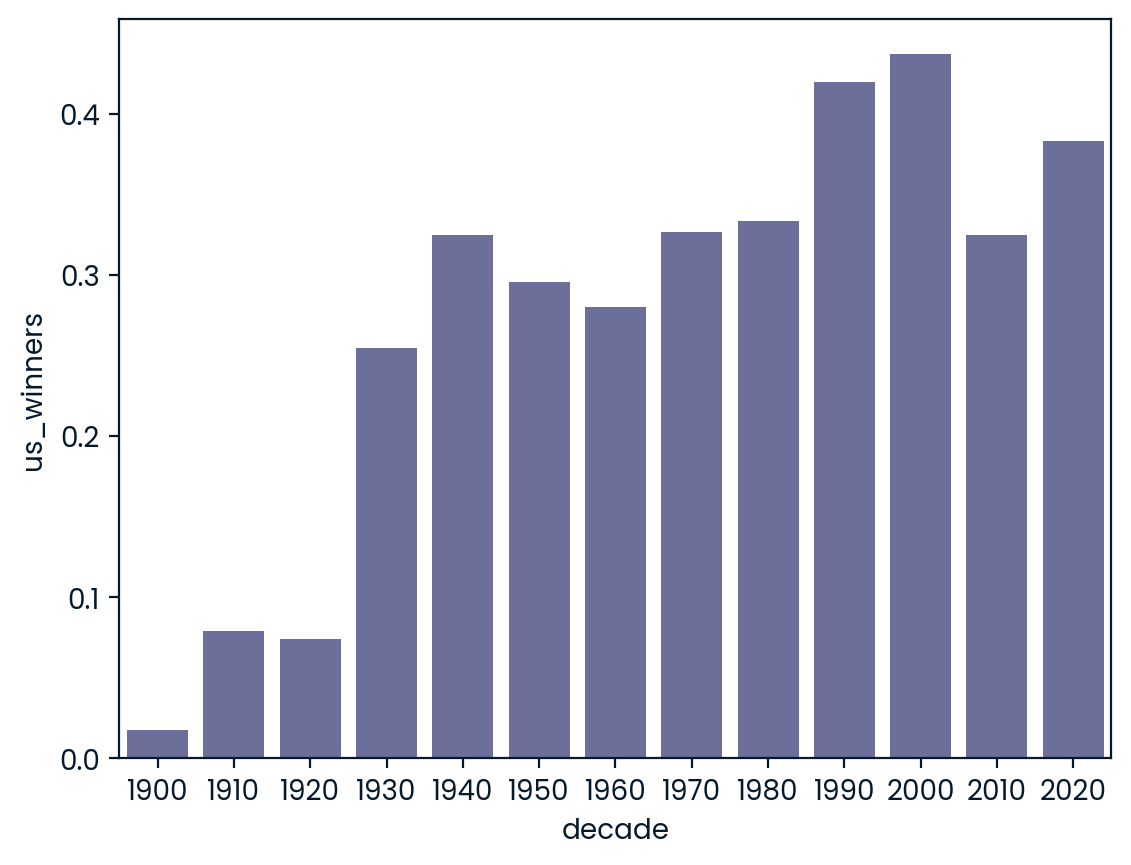

In [110]:
import matplotlib.pyplot as plt

sns.barplot(data = nobel, y = 'us_winners', x = 'decade', ci = None)
plt.show()

In [111]:
max_decade_usa = us_winners_per_decade.idxmax()
print(max_decade_usa)

2000


## 3) Which decade and Nobel Prize category combination had the highest proportion of female laureates?

Store this as a dictionary called **_max_female_dict_** where the decade is the key and the category is the value. 

In [112]:
# Create a Flag Column for Female Winners (1 = Female, 0 = Male)
nobel['female_winners'] = (nobel['sex'] == 'Female').astype(int)

#  Count Female Winners per Decade
female_winners_per_decade =  nobel.groupby(['decade','category'])['female_winners'].mean().round(4)
female_winners_per_decade.sort_values(ascending = False).head() # the 5 decades with the highest ratio of US winners

decade  category  
2020    Peace         0.5
        Literature    0.5
2010    Peace         0.5
1990    Literature    0.3
2000    Literature    0.3
Name: female_winners, dtype: float64

In [113]:
max_female_entry = female_winners_per_decade.sort_values(ascending=False).idxmax()
max_female_entry

(2020, 'Peace')

In [114]:
max_female_dict = {max_female_entry[0]:max_female_entry[1]}
print(max_female_dict)

{2020: 'Peace'}


## 4) Who was the first woman to receive a Nobel Prize, and in what category?

Save your string answers as **_first_woman_name_** and **_first_woman_category_**.

In [116]:
first_female_winners = female_winners[['year','full_name','category']].sort_values('year').reset_index(drop = True)

first_female_winners.head()

,year,full_name,category
0,1903,"Marie Curie, née Sklodowska",Physics
1,1905,"Baroness Bertha Sophie Felicita von Suttner, n...",Peace
2,1909,Selma Ottilia Lovisa Lagerlöf,Literature
3,1911,"Marie Curie, née Sklodowska",Chemistry
4,1926,Grazia Deledda,Literature


In [117]:
first_woman_name = first_female_winners.iloc[0,1]
print("the first woman to receive a Nobel Prize was",first_woman_name)

first_woman_category = first_female_winners.iloc[0,2]
print("in the Category of",first_woman_category)

the first woman to receive a Nobel Prize was Marie Curie, née Sklodowska
in the Category of Physics


## 5) Which individuals or organizations have won more than one Nobel Prize throughout the years?

Store the full names in a list named **_repeat_list_**.

In [118]:
winners_count = df['full_name'].value_counts()

winners_count[winners_count > 1]

Comité international de la Croix Rouge (International Committee of the Red Cross)    3
Linus Carl Pauling                                                                   2
John Bardeen                                                                         2
Frederick Sanger                                                                     2
Marie Curie, née Sklodowska                                                          2
Office of the United Nations High Commissioner for Refugees (UNHCR)                  2
Name: full_name, dtype: int64

In [119]:
repeat_list = winners_count[winners_count > 1].index.tolist()
repeat_list

['Comité international de la Croix Rouge (International Committee of the Red Cross)',
 'Linus Carl Pauling',
 'John Bardeen',
 'Frederick Sanger',
 'Marie Curie, née Sklodowska',
 'Office of the United Nations High Commissioner for Refugees (UNHCR)']